Mahla Entezari 

In [1]:
# pip install matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In the code snippet below, I defined an image class that can be used to transfer the image from the path to the matrix

In [3]:
class Image:
    def __init__(self,path):
        self.path = path
    def read(self):
        img = plt.imread( self.path )
        return img

Here, I will depict the matrix with the help of plt

In [4]:
def display(image):
    plt.imshow(image)
    plt.gca().set_xlabel( 'x' )
    plt.gca().set_ylabel( 'y' )

In the resizing method, I take the desired scale for resizing and create a matrix with a new scale, which is the zero matrix first, and then I fill the cells corresponding to each cell with the help of the original image matrix.

In [5]:
def resize_image(image):
    scale=int(input())
    h=get_dimensions(image)[0]
    w=get_dimensions(image)[1]
    new_h=int(h*scale/100)
    new_w=int(w*scale/100)
    new_image = np.zeros((new_h,new_w))
    for i in range(new_h):
        for j in range(new_w):
            new_image[i][j] = image[int(i/scale * 100)][int(j/scale * 100)][0]
    display(new_image)
    print(get_dimensions(new_image))


 In the rotation method, I replace each cell with its corresponding cell, but instead of swapping, I used the new matrix

In [6]:
def rotate(image):
    h=get_dimensions(image)[0]
    w=get_dimensions(image)[1]
    new_image = np.zeros((w,h))
    for i in range(h):
        for j in range(w):
            new_image[j][h-1-i] = image[i][j][0]
    display(new_image)


 In this part, I return the dimensions of the matrix

In [7]:
def get_dimensions(image):
    dimensions = image.shape
    return dimensions

 To blur the image, I use a kernel matrix in such a way that the center of the kernel matrix is scrolled throughout the desired area (here, the entire image) and I change every cell of the matrix to a random number obtained from the normal distribution.

In [8]:
def blur(image):
    kernel_size = 5
    blur_kernel = np.ones((kernel_size, kernel_size)) / (kernel_size**2)
    blurred_image = np.zeros_like(image, dtype=np.uint8)
    for i in range(3):
        blurred_image[:,:,i] = np.convolve(image[:,:,i].ravel(), blur_kernel.ravel(), mode='same').reshape(image.shape[:2])
    display(blurred_image)


First,I loop over the three color channels(RGB).For each color channel,flatten the channel and the sharpening kernel, perform convolution using np.convolve, and then reshape the result back to the shape of the original image.At last ,ensure they are within the valid range (0 to 255).

In [9]:
def sharpening(image):
    sharpening_kernel = np.array([[-1, -1, -1],
                                  [-1,  9, -1],
                                  [-1, -1, -1]])
    sharpened_image = np.zeros_like(image, dtype=np.uint8)
    for i in range(3):
        sharpened_image[:,:,i] = np.clip(np.convolve(image[:,:,i].ravel(), sharpening_kernel.ravel(), mode='same').reshape(image.shape[:2]), 0, 255)
    display(sharpened_image)


I produce the color channel of the image into a multiplication matrix so that the color range falls within the range of the gray range.

In [10]:
def grayscale_conversion(image):
    return np.dot(image[..., :3], [0.128, 0.128, 0.128])

I replace each color with its complementary color.

In [11]:
def color_inversion(image):
    image = 255-image
    display(image)

I multiply the colors in the input scale.

In [12]:
def color_adjust(image,scale_R,scale_G,scale_B):
    new_image = np.zeros_like(image, dtype=np.float32)
    new_image[..., 0] = image[..., 0] * scale_R
    new_image[..., 1] = image[..., 1] * scale_G
    new_image[..., 2] = image[..., 2] * scale_B
    new_image = np.clip(new_image, 0, 255).astype(np.uint8)
    display(new_image)

First, I take the image to the gray scale.Then,I define two matrices to detect edges in vertical and horizontal mode . Then  calculates the gradients in the x and y directions, emphasizing edges.The magnitudes of the gradients in the x and y directions are combined to calculate the overall edge magnitude using the Euclidean distance formula.

In [13]:
def edge_detection(img):
    image = grayscale_conversion(img)
    x_kernel = np.array([[-1, 0, 1],
                               [-2, 0, 2],
                               [-1, 0, 1]])

    y_kernel = np.array([[-1, -2, -1],
                               [0, 0, 0],
                               [1, 2, 1]])
    sobel_x = np.abs(np.convolve(image.ravel(), x_kernel.ravel(), mode='same').reshape(image.shape))
    sobel_y = np.abs(np.convolve(image.ravel(), y_kernel.ravel(), mode='same').reshape(image.shape))
    edge_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    display(edge_magnitude)

In [14]:
path = 'wallpaper.jpg'
imageee = Image(path)
image = imageee.read()

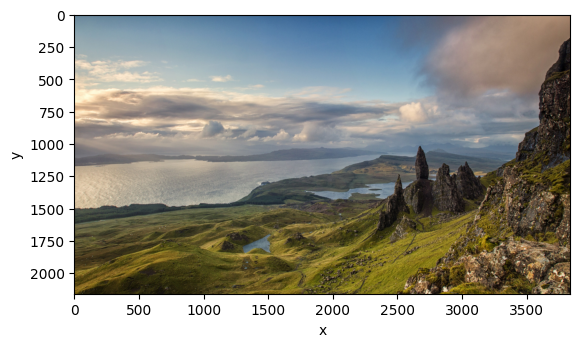

In [15]:
display(image)

In [16]:
print(get_dimensions(image))

(2160, 3840, 3)


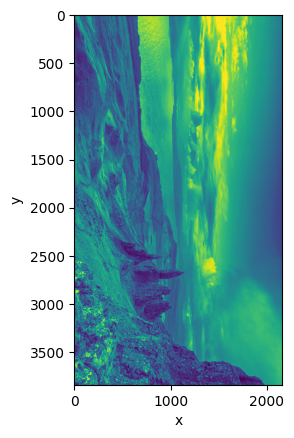

In [17]:
rotate(image)

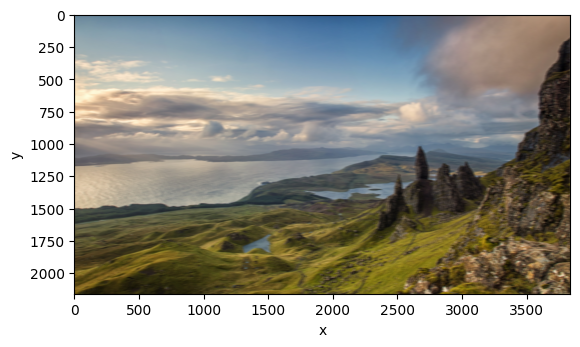

In [18]:
blur(image)

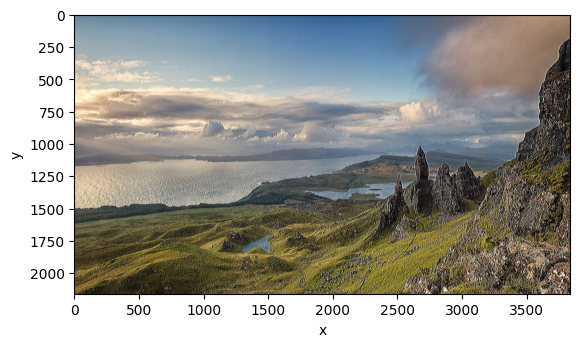

In [19]:
sharpening(image)

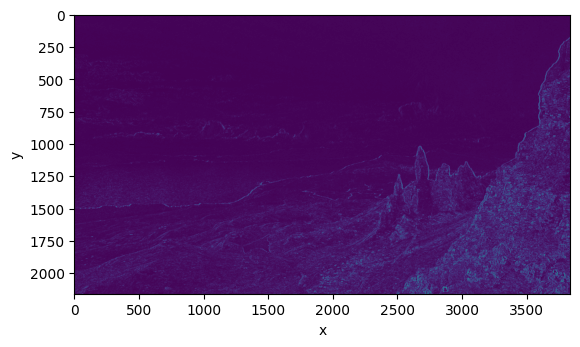

In [20]:
edge_detection(image)

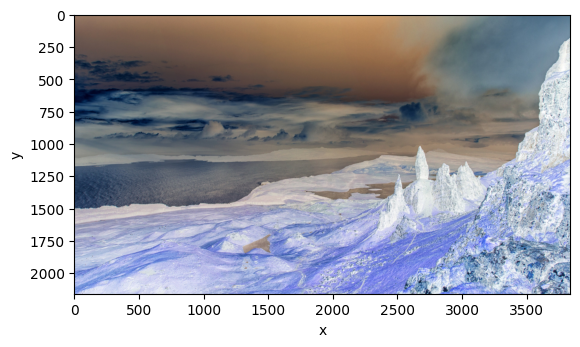

In [21]:
color_inversion(image)

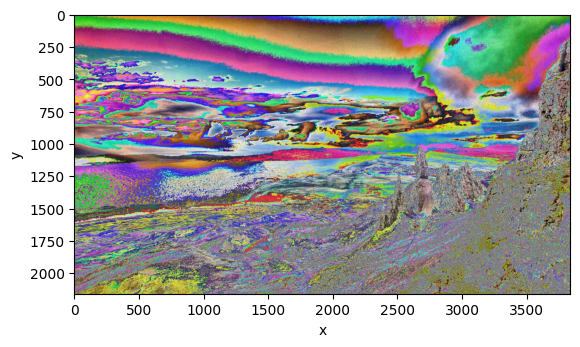

In [22]:
color_adjust(image, 5, 5, 5)

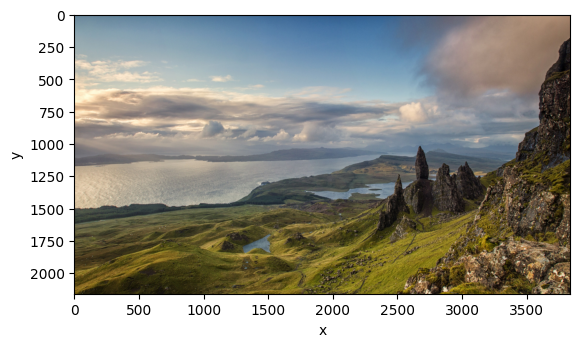

In [25]:
cmd = int(input("Enter a command (1-9): "))

if cmd == 1:
    display(image)
elif cmd == 2:
    print(get_dimensions(image))
elif cmd == 3:
    resize_image(image)
elif cmd == 4:
    rotate(image)
elif cmd == 5:
    blur(image)
elif cmd == 6:
    sharpening(image)
elif cmd == 7:
    edge_detection(image)
elif cmd == 8:
    color_inversion(image)
elif cmd == 9:
    color_adjust(image, 5, 5, 5)
else:
    print("Invalid command.")
